1. Install Library

In [ ]:
!pip install pandas numpy tensorflow scikit-learn keras wordcloud matplotlib


2. Load dan Encode Data

In [1]:
import pandas as pd

# Load file
file_path = 'D:/Kerjaan/Project P68800125 (Model Indobert with CNN-LTSM)/FIX data_label 3 kls.xlsx'
df = pd.read_excel(file_path)

# Tampilkan data untuk memastikan
print(df.head())

# Encode label menjadi 0 (negatif), 1 (netral), 2 (positif)
df['label'] = df['label'].map({'negative': 0, 'neutral': 1, 'positive': 2})


   Unnamed: 0                 created_at  \
0           1  2022-01-27 12:29:56+00:00   
1           2  2022-01-27 11:33:49+00:00   
2           3  2022-01-27 09:40:40+00:00   
3           4  2022-01-27 04:39:49+00:00   
4           5  2022-01-27 00:30:58+00:00   

                                           full_text     username  \
0  gpp company lokal asal WFA, mungkin bukan peng...      xyberya   
1  @arifsyh86 @pipis @MrsEuscha @tbputera Sorry b...    ninanenen   
2  Yay nambah opsi baru wfa spot di cibi ????????...      mirzarm   
3  Jadi pelaksana proyek susah kalo wfa. Apalagi ...  segedegabun   
4  tujuan karir sekarang fokusnya lebih ke work l...      favophs   

                                               clean  \
0  gpp company lokal asal wfa mungkin bukan penge...   
1  sorry baru liat notif tidak harus di jakarta k...   
2              yay nambah opsi baru wfa spot di cibi   
3  jadi pelaksana proyek susah kalo wfa apalagi a...   
4  tujuan karir sekarang fokusnya lebih 

3. Split Data untuk Training dan Testing

In [2]:
from sklearn.model_selection import train_test_split

X = df['teks']  # Fitur: kolom teks
y = df['label']  # Label: kolom polaritas

# Split data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah data training: {len(X_train)}")
print(f"Jumlah data testing: {len(X_test)}")


Jumlah data training: 10919
Jumlah data testing: 2730


4. Tokenisasi dan Padding

In [3]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Pastikan data dalam bentuk string
X_train = X_train.astype(str)
X_test = X_test.astype(str)

# Tokenisasi
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X_train)

# Ubah teks menjadi urutan angka
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding agar panjangnya seragam
maxlen = 100  # Panjang maksimal setiap teks
X_train_pad = pad_sequences(X_train_seq, maxlen=maxlen, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=maxlen, padding='post')


5. Konversi Label ke One-Hot Encoding

In [4]:
from tensorflow.keras.utils import to_categorical

# Konversi label ke one-hot encoding
y_train = to_categorical(y_train, num_classes=3)
y_test = to_categorical(y_test, num_classes=3)


6. Bangun Model CNN-LSTM

In [5]:
from keras.models import Sequential
from keras.layers import Embedding, Conv1D, MaxPooling1D, LSTM, Dense, Dropout

# Parameter
embedding_dim = 128

# Bangun model
model = Sequential()
model.add(Embedding(input_dim=5000, output_dim=embedding_dim, input_length=maxlen))
model.add(Conv1D(filters=64, kernel_size=3, activation='relu'))
model.add(MaxPooling1D(pool_size=2))
model.add(LSTM(70))
model.add(Dropout(0.5))
model.add(Dense(3, activation='softmax'))  # 3 kelas dengan softmax

# Kompilasi model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Tampilkan ringkasan model
model.summary()


c:\Users\LENOVO\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

7. Train Model

In [6]:
history = model.fit(
    X_train_pad, y_train,
    batch_size=32,
    epochs=10,
    validation_split=0.2,
    verbose=1
)


Epoch 1/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.5317 - loss: 1.0024 - val_accuracy: 0.6465 - val_loss: 0.8235
Epoch 2/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.5419 - loss: 1.0080 - val_accuracy: 0.6410 - val_loss: 0.8245
Epoch 3/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.6648 - loss: 0.7784 - val_accuracy: 0.6735 - val_loss: 0.7670
Epoch 4/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.7266 - loss: 0.6522 - val_accuracy: 0.6722 - val_loss: 0.7726
Epoch 5/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.7511 - loss: 0.5760 - val_accuracy: 0.6571 - val_loss: 0.8326
Epoch 6/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.7805 - loss: 0.4988 - val_accuracy: 0.6548 - val_loss: 0.8789
Epoch 7/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.7980 - loss: 0.4532 - val_accuracy: 0.6488 - val_loss: 0.9726
Epoch 8/10
273/273 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.8404 - loss: 0.3920 - val_acc

8. Evaluasi Model

In [7]:
# Evaluasi
score, acc = model.evaluate(X_test_pad, y_test, verbose=1)
print(f"Test Score: {score}")
print(f"Test Accuracy: {acc}")


86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6946 - loss: 1.0072
Test Score: 1.0258643627166748
Test Accuracy: 0.6853479743003845


9. Metrik Evaluasi

In [8]:
from sklearn.metrics import classification_report

# Prediksi kelas
y_pred_prob = model.predict(X_test_pad)
y_pred = y_pred_prob.argmax(axis=1)  # Ambil indeks kelas dengan probabilitas tertinggi
y_test_labels = y_test.argmax(axis=1)  # Konversi y_test dari one-hot ke label asli

# Laporan klasifikasi
print("Classification Report:")
print(classification_report(y_test_labels, y_pred, target_names=['Negative', 'Neutral', 'Positive']))


86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Classification Report:
              precision    recall  f1-score   support

    Negative       0.64      0.58      0.61       753
     Neutral       0.79      0.79      0.79      1497
    Positive       0.45      0.53      0.48       480

    accuracy                           0.69      2730
   macro avg       0.63      0.63      0.63      2730
weighted avg       0.69      0.69      0.69      2730



10. Visualisasi Akurasi

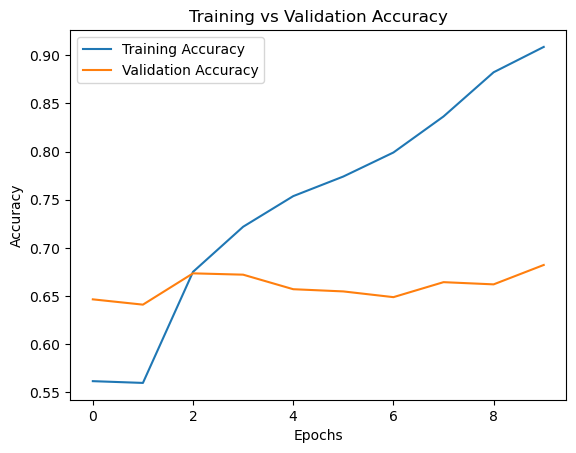

In [9]:
import matplotlib.pyplot as plt

# Plot akurasi
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()


11. Pie Chart untuk Distribusi Kelas

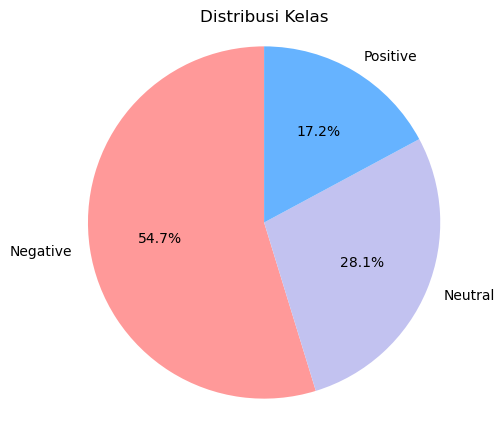

In [10]:
# Hitung jumlah masing-masing kelas
class_counts = df['label'].value_counts()
labels = ['Negative', 'Neutral', 'Positive']
colors = ['#ff9999', '#c2c2f0', '#66b3ff']

# Plot pie chart
plt.figure(figsize=(5, 5))
plt.pie(class_counts, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Distribusi Kelas')
plt.axis('equal')
plt.show()


12. WordCloud untuk Setiap Kelas

In [11]:
# Ubah semua elemen di kolom teks menjadi string
df['teks'] = df['teks'].fillna("").astype(str)


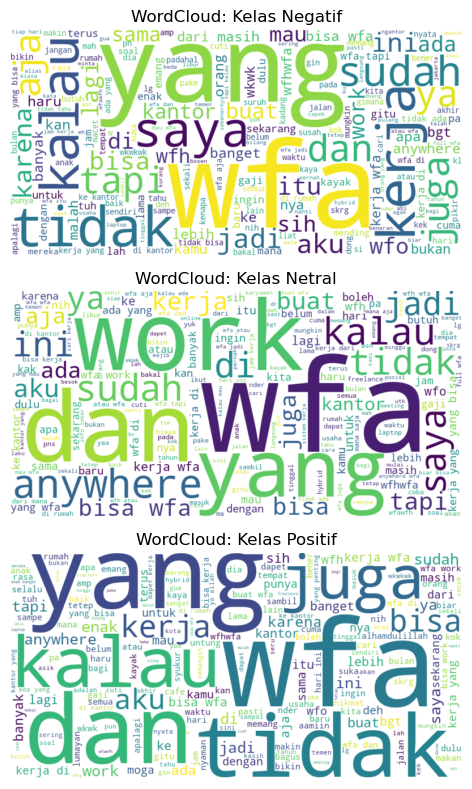

In [12]:
from wordcloud import WordCloud

# Pisahkan teks berdasarkan kelas
negative_texts = ' '.join(df[df['label'] == 0]['teks'])
neutral_texts = ' '.join(df[df['label'] == 1]['teks'])
positive_texts = ' '.join(df[df['label'] == 2]['teks'])

# WordCloud untuk setiap kelas
negative_wc = WordCloud(width=800, height=400, background_color='white').generate(negative_texts)
neutral_wc = WordCloud(width=800, height=400, background_color='white').generate(neutral_texts)
positive_wc = WordCloud(width=800, height=400, background_color='white').generate(positive_texts)

# Plot WordCloud
plt.figure(figsize=(8, 8))

# Kelas Negatif
plt.subplot(3, 1, 1)
plt.imshow(negative_wc, interpolation='bilinear')
plt.title('WordCloud: Kelas Negatif')
plt.axis('off')

# Kelas Netral
plt.subplot(3, 1, 2)
plt.imshow(neutral_wc, interpolation='bilinear')
plt.title('WordCloud: Kelas Netral')
plt.axis('off')

# Kelas Positif
plt.subplot(3, 1, 3)
plt.imshow(positive_wc, interpolation='bilinear')
plt.title('WordCloud: Kelas Positif')
plt.axis('off')

plt.tight_layout()
plt.show()
